In [1]:
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_csv("../coverage_stats.csv")
df2 = pd.read_csv("../coverage_stats_alpha1p2.csv")

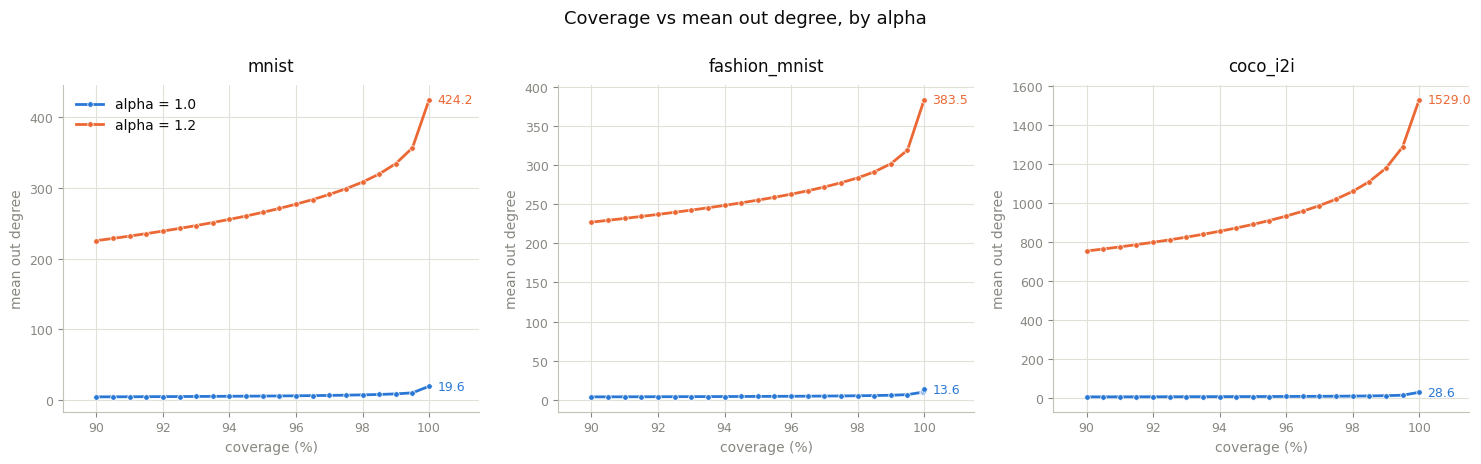

In [5]:
import matplotlib.pyplot as plt

DATASETS = ["mnist", "fashion_mnist", "coco_i2i"]
METHOD = "robust-prune"  # df2 has no set-cover rows, so restrict both for a like-for-like comparison

# Categorical slots 1 and 2: validated as a pair (CVD ΔE 24.7, normal 33.6).
SERIES = [(df1, "alpha = 1.0", "#2a78d6"), (df2, "alpha = 1.2", "#eb6834")]

MUTED, GRID, INK = "#898781", "#e1e0d9", "#0b0b0b"

# Each panel scales to its own data, so compare curve shapes across panels,
# not heights. Within a panel the two alphas do share one axis.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

for ax, ds in zip(axes, DATASETS):
    for df, label, color in SERIES:
        sub = (df[(df["dataset"] == ds) & (df["method"] == METHOD)]
               .sort_values("coverage"))
        if sub.empty:
            continue
        ax.plot(sub["coverage"], sub["mean out degree"],
                color=color, linewidth=2, marker="o", markersize=4,
                markeredgecolor="white", markeredgewidth=0.5, label=label)
        # Direct-label the endpoint so identity never rests on color alone.
        ax.annotate(f"{sub['mean out degree'].iloc[-1]:.1f}",
                    (sub["coverage"].iloc[-1], sub["mean out degree"].iloc[-1]),
                    textcoords="offset points", xytext=(6, 0),
                    va="center", fontsize=9, color=color)

    ax.set_title(ds, fontsize=12, color=INK, pad=10)
    ax.set_xlabel("coverage (%)", fontsize=10, color=MUTED)
    ax.set_ylabel("mean out degree", fontsize=10, color=MUTED)
    ax.set_xlim(89, 101.5)  # headroom so endpoint labels don't clip
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUTED, labelsize=9)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")

axes[0].legend(frameon=False, fontsize=10, labelcolor=INK, loc="upper left")

fig.suptitle("Coverage vs mean out degree, by alpha", fontsize=13, color=INK, y=1.0)
fig.tight_layout()
plt.show()